In [1]:
import pennylane as qml
from scipy.linalg import expm 
from pennylane import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt

## Fidelity test

In [2]:
num_qubits =11
sys_size = 5
dev = qml.device('default.qubit', wires=num_qubits)
@qml.qnode(dev)
def Fidelity(O1,O2):
    for i in range(num_qubits-1):
        qml.Hadamard(wires=i)
    qml.QubitUnitary(O1, wires=range(sys_size))
    qml.QubitUnitary(O2, wires=range(sys_size,num_qubits-1))
    qml.Hadamard(wires=num_qubits-1)
    qml.Barrier()
    for i in range(sys_size):
        qml.ctrl(qml.SWAP(wires=(i,i+sys_size)), control=num_qubits-1)
    qml.Hadamard(wires=num_qubits-1)
    return qml.expval(qml.Z(wires=num_qubits-1))
    #return qml.probs(wires=num_qubits-1)

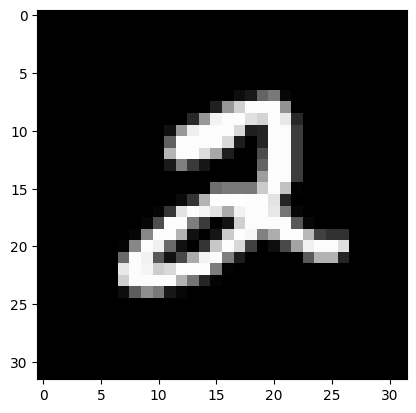

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_n1 = x_train[y_train == 2]
x_train_n1_32 = np.pad(x_train_n1, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image1 = x_train_n1_32[0]

plt.imshow(Image1, cmap='gray')
plt.show()

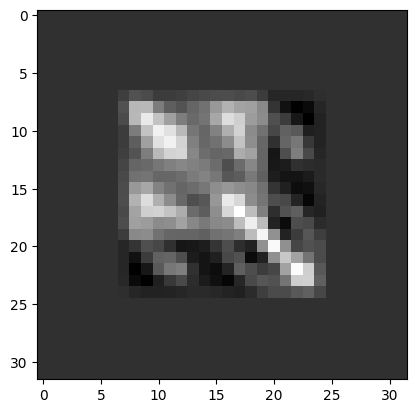

In [4]:
plt.imshow(np.cov(Image1), cmap='gray')

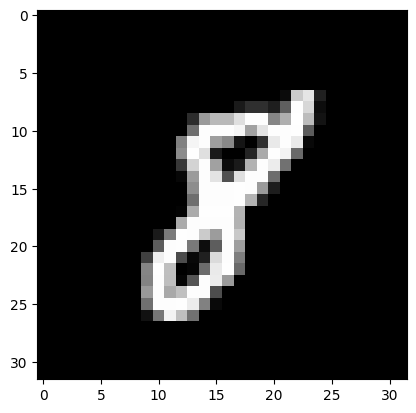

In [5]:
x_train_n2 = x_train[y_train == 8]
x_train_n2_32 = np.pad(x_train_n2, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image2 = x_train_n2_32[0]

plt.imshow(Image2, cmap='gray')
plt.show()

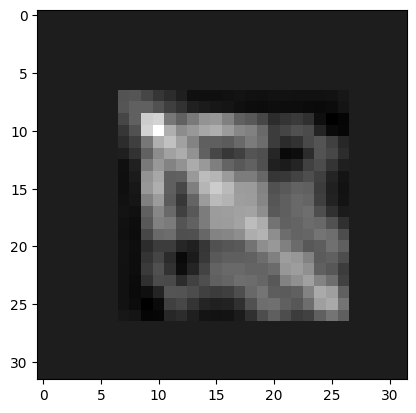

In [6]:
plt.imshow(np.cov(Image2), cmap='gray')

In [7]:
Img1_O = expm(1j*np.cov(Image1/255))
Img2_O = expm(1j*np.cov(Image2/255))
print(np.allclose(Img1_O@Img1_O.conj().T,np.eye(2**sys_size)))
print(np.allclose(Img2_O@Img2_O.conj().T,np.eye(2**sys_size)))


True
True


In [8]:
O1 = np.random.uniform(0,1, size=(2**sys_size, 2**sys_size))
O2 = np.random.uniform(0,1, size=(2**sys_size, 2**sys_size))
O1 = O1*O1.T
O2 = O2*O2.T
O1 = expm(1j*O1)
O1 = expm(1j*O1)
print(np.allclose(O1@O1.conj().T,np.eye(2**sys_size)))
print(np.allclose(O2@O2.conj().T,np.eye(2**sys_size)))

False
False


(<Figure size 1200x1200 with 1 Axes>, <Axes: >)


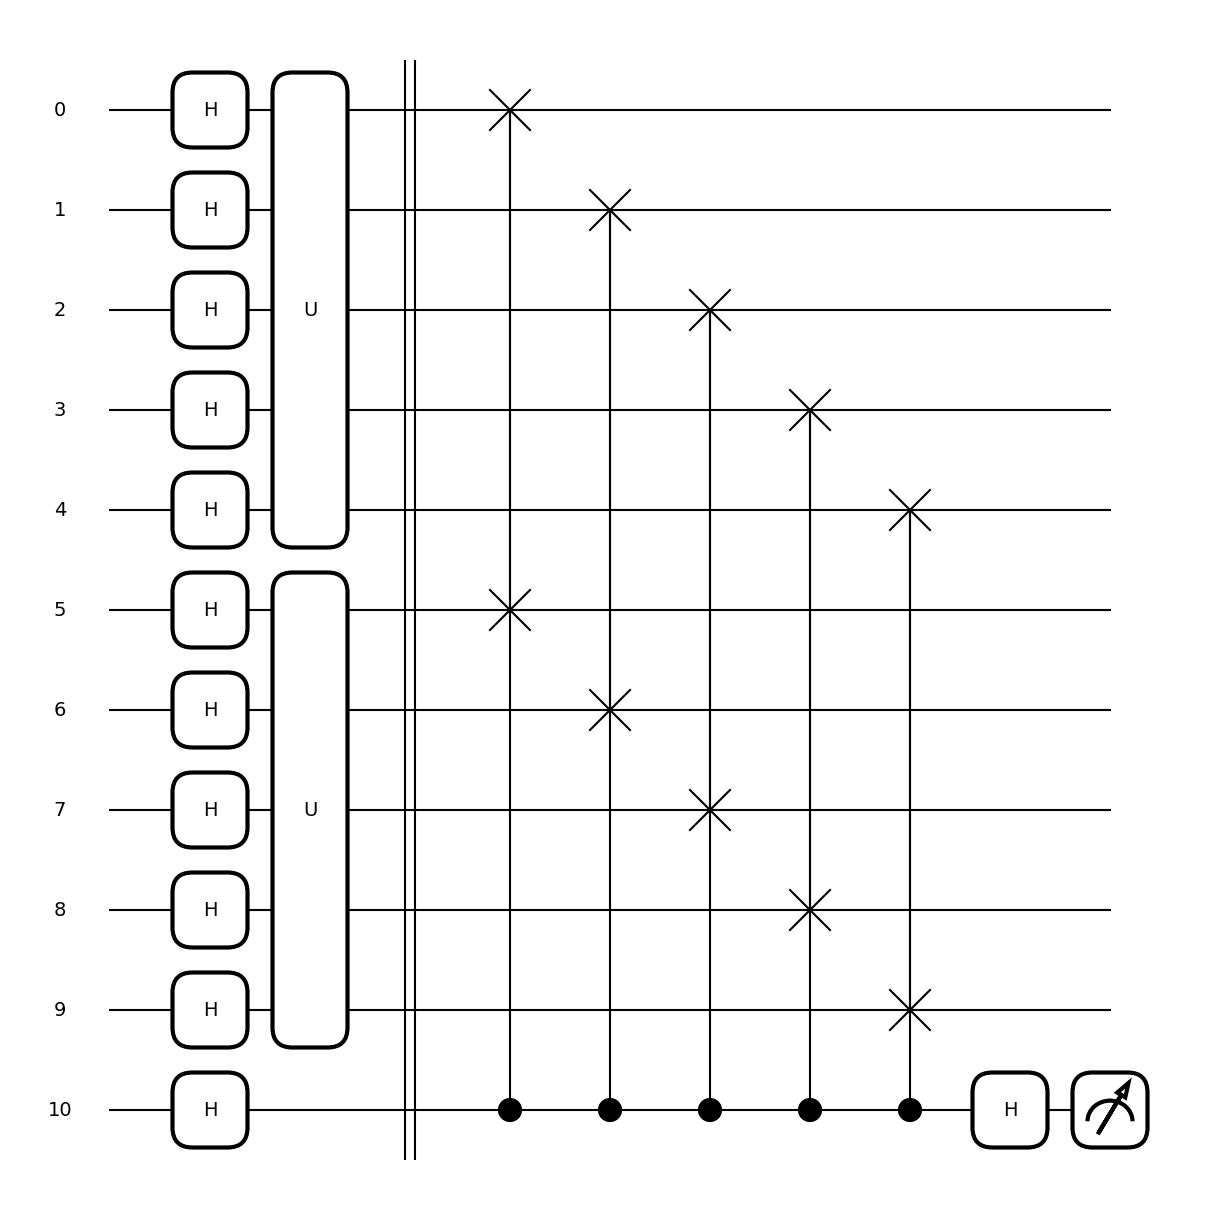

In [9]:
circuit = qml.QNode(Fidelity,dev)
print(qml.draw_mpl(circuit)(Img1_O,Img2_O))

In [10]:
np.allclose(Img1_O,Img2_O)

False

In [11]:
l = circuit(Img1_O,Img2_O)
print(l)

0.9113848056598239


In [12]:
l = circuit(Img1_O,Img1_O)
print(l)

1.0000000000000007


## Traing and classification

In [13]:
import sys
sys.path.append('../')

In [14]:
import pennylane as qml
from pennylane import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
from scipy.linalg import expm
from random import sample as smp
#from qpbl.QPBL import Eigen, Utils, Mottonen

In [15]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_n = x_train[y_train == 2]
x_train_n_32 = np.pad(x_train_n, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)

Img_O = np.zeros_like(x_train_n_32, dtype=complex)

for (i,img) in enumerate(x_train_n_32):
    I = np.cov(img/255.0)
    Img_O[i] = expm(1j * I)

In [16]:
from pennylane.operation import Operation#, AnyWires


class Eigen(Operation):
    #num_wires = AnyWires
    #num_params = 6

    def __init__(self, theta: np.ndarray , wire = None, IndexQubits: int = 2, LQubits: int = 5, QQubits: int = 2, O : np.ndarray = None, T : str = "X"):
        self._hyperparameters = {
            "IndexQubits": IndexQubits,
            "LQubits": LQubits,
            "QQubits": QQubits,
            "O": O ,
            "T": T,
        }
        super().__init__(theta,wires=wire)
    
    @staticmethod
    def compute_decomposition(theta: np.ndarray, wires, IndexQubits: int, LQubits: int = 5, QQubits: int = 2, O : np.ndarray = None, T : str = "X") -> list[Operation]:
        """Compute the decomposition of the Eigen operation."""
        n_params = 0 #len(theta) Temporaly there is not going to be training by
        offset_L = n_params + IndexQubits
        offset_U = n_params + IndexQubits + LQubits
        n_qubits = n_params + IndexQubits + LQubits + QQubits
        op_list = []
        for i in range(LQubits):
            op_list.append(qml.Hadamard(wires=i+offset_L))
        for i in range(LQubits):
            op_list.append(qml.ctrl(qml.QubitUnitary(Utils.powm(O,i), wires=range(offset_U,n_qubits)), control=offset_U-1-i))
        op_list.append(qml.adjoint(qml.QFT(wires=range(offset_L, offset_U))))
        
        return op_list

class Mottonen(Operation):
    #num_wires = AnyWires
    
    def __init__(self, theta: np.ndarray , wire = None, QQubits: int =2, offset_U: int = 5):
        self._hyperparameters = {
            "QQubits": QQubits,
            "offset_U": offset_U,
        }
        super().__init__(theta,wires=wire)
    
    @staticmethod
    def compute_decomposition(theta: np.ndarray, wires, QQubits: int = 2,  offset_U: int = 5) -> list[Operation]:
        op_list = []
        c = 2**QQubits -2
        for k,i in enumerate(range(QQubits-1, -1, -1)):
            for j in range(2**k-1,-1,-1):
                if k>0:
                    op_list.append(qml.ctrl(qml.adjoint(qml.RY(theta[c], wires=k+offset_U)), control=range(offset_U,k+offset_U), control_values=Utils.int_to_bin(j,k)))
                else:
                    op_list.append(qml.adjoint(qml.RY(theta[c], wires=k+QQubits)))
                c = c - 1
        return op_list

class Utils():

    def __init__(self):
        pass

    @staticmethod
    def int_to_bin(n, num_bits)-> tuple:
        return tuple(int(x) for x in format(n, f'0{num_bits}b'))
    
    @staticmethod
    def powm(M,p):
        if p == 0:
            return M
        T = M@M
        for i in range(1,p):
            T = T@T
        return T

## Trainig without superposition

In [17]:
IQubits = 0
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev3 = qml.device('default.qubit', wires=nQubits) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qnode(dev3)
def circuitMNS(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

CMNS = qml.QNode(circuitMNS, dev3)


(<Figure size 700x1100 with 1 Axes>, <Axes: >)


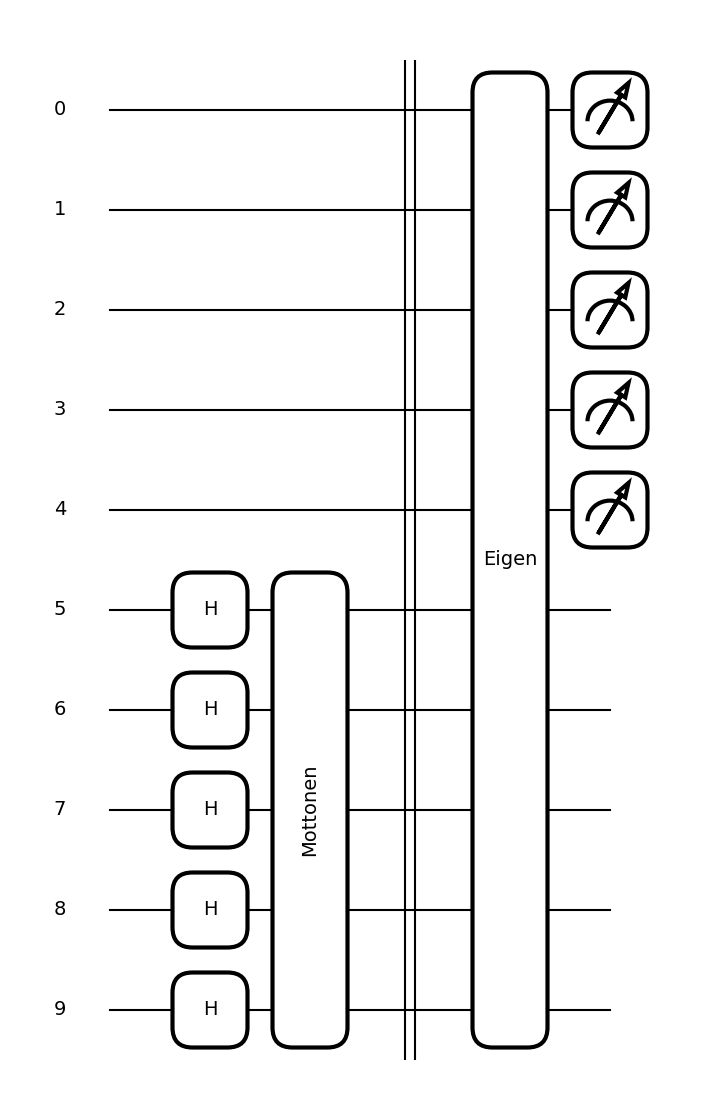

In [18]:
theta = np.random.uniform(0,np.pi,size=2**QQubits-1)
theta_2 = np.zeros_like(theta)
print(qml.draw_mpl(CMNS)(theta_2,Img_O[:2**IQubits]))

In [19]:
def loss_MSE2(weights,O, opt):
    """Computes the cost over the provided features and labels"""
    preds = CMNS(weights, O, opt)
    return (np.tensor(1.00)-preds) ** 2


def train2(image_data_train, iter=20, lr=0.1, opt = True, randonmized=False):
    weights = np.array(np.random.uniform(0,np.pi,size=(num_layers,2**QQubits -1)), requires_grad=True) # initialize weights
    opt = qml.GradientDescentOptimizer(stepsize=lr) # gradient optimizer
    if randonmized:
        img_idxs = smp(range(len(image_data_train)),2**IQubits)
        image_data_train_2 = image_data_train[img_idxs]
    else:
        image_data_train_2 = image_data_train[:2**IQubits]
    for i in range(iter):
        weights, loss = opt.step_and_cost(lambda w: loss_MSE2(w, image_data_train_2, opt), weights)
        #if i % 50 == 0:
        print(f"Epoch {i+1}, {loss}:")
    return weights

In [67]:
trained_weights2 = train2(Img_O[:2**IQubits], iter=50000, lr=0.3)

Epoch 1, 0.9844296852336792:
Epoch 2, 0.9842425418484633:
Epoch 3, 0.984053917136745:
Epoch 4, 0.983863816203788:
Epoch 5, 0.9836722445015222:
Epoch 6, 0.98347920782848:
Epoch 7, 0.9832847123294993:
Epoch 8, 0.983088764495193:
Epoch 9, 0.9828913711611769:
Epoch 10, 0.9826925395070629:
Epoch 11, 0.9824922770552115:
Epoch 12, 0.9822905916692446:
Epoch 13, 0.9820874915523181:
Epoch 14, 0.9818829852451563:
Epoch 15, 0.9816770816238451:
Epoch 16, 0.9814697898973888:
Epoch 17, 0.9812611196050278:
Epoch 18, 0.981051080613324:
Epoch 19, 0.9808396831130084:
Epoch 20, 0.9806269376156008:
Epoch 21, 0.9804128549497991:
Epoch 22, 0.9801974462576438:
Epoch 23, 0.9799807229904587:
Epoch 24, 0.9797626969045737:
Epoch 25, 0.9795433800568335:
Epoch 26, 0.9793227847998932:
Epoch 27, 0.9791009237773107:
Epoch 28, 0.9788778099184362:
Epoch 29, 0.9786534564331071:
Epoch 30, 0.9784278768061511:
Epoch 31, 0.9782010847917073:
Epoch 32, 0.9779730944073661:
Epoch 33, 0.9777439199281406:
Epoch 34, 0.9775135758802

## Trainig with superposition

In [20]:
IQubits = 5
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev2 = qml.device('default.qubit', wires=nQubits) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qnode(dev2)
def circuitM(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

(<Figure size 3800x1600 with 1 Axes>, <Axes: >)


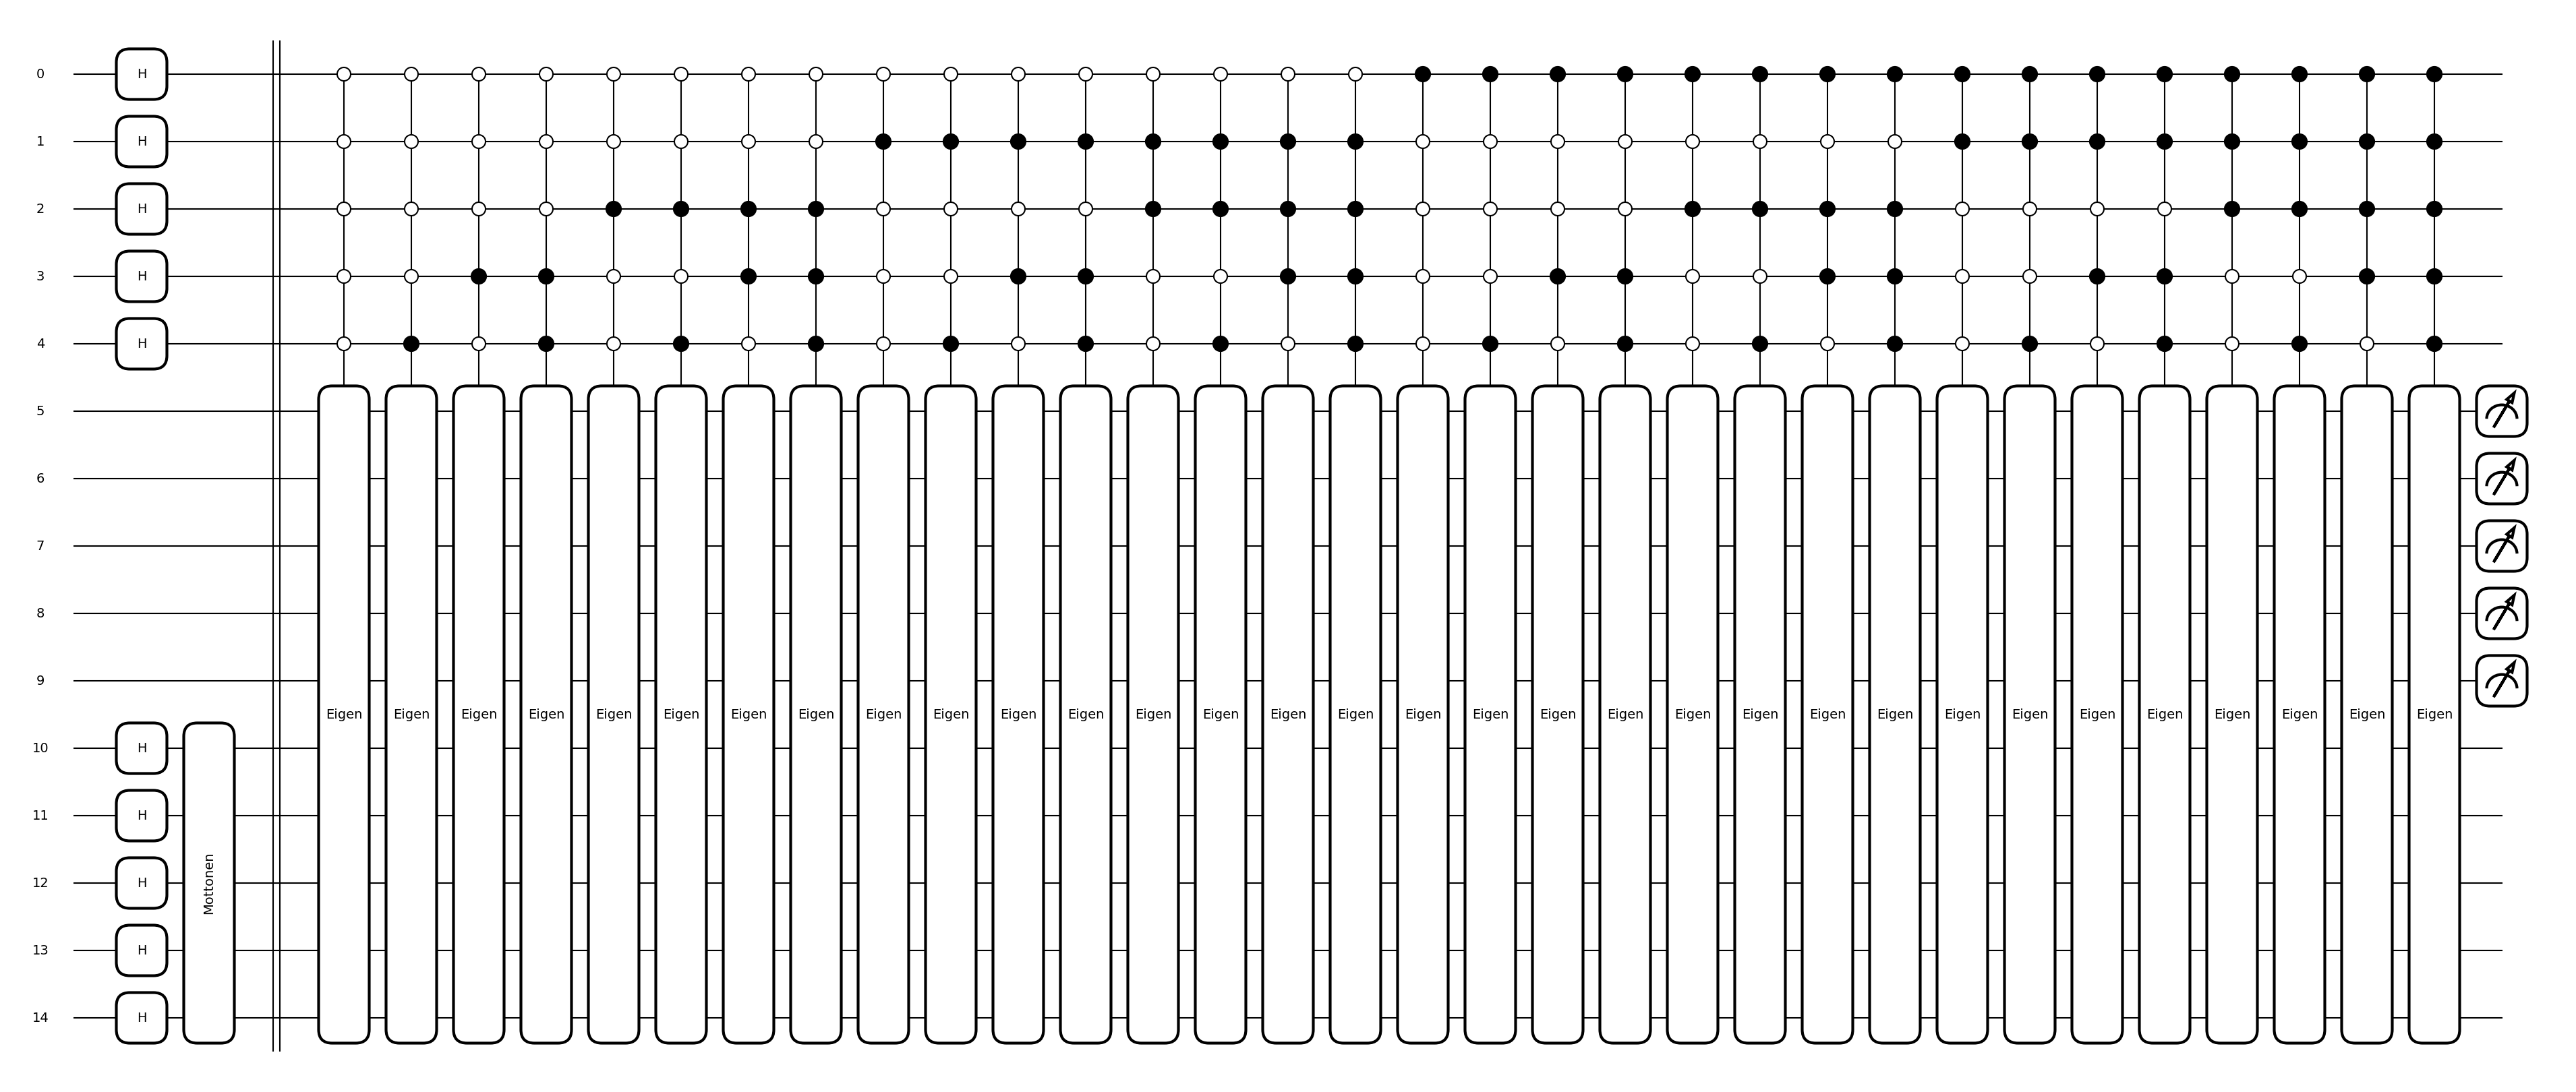

In [21]:
CM = qml.QNode(circuitM,dev2)
theta = np.random.uniform(0,np.pi,size=2**QQubits-1)
theta_2 = np.zeros_like(theta)
print(qml.draw_mpl(CM)(theta_2,Img_O[:2**IQubits]))

In [22]:
def loss_MSE(weights,O, opt):
    """Computes the cost over the provided features and labels"""
    preds = circuitM(weights, O, opt)
    return (np.tensor(1.00)-preds) ** 2


def train(image_data_train, iter=20, lr=0.1, opt = True, randonmized=False):
    weights = np.array(np.random.uniform(0,np.pi,size=(num_layers,2**QQubits -1)), requires_grad=True) # initialize weights
    opt = qml.GradientDescentOptimizer(stepsize=lr) # gradient optimizer
    if randonmized:
        img_idxs = smp(range(len(image_data_train)),2**IQubits)
        image_data_train_2 = image_data_train[img_idxs]
    else:
        image_data_train_2 = image_data_train[:2**IQubits]
    for i in range(iter):
        weights, loss = opt.step_and_cost(lambda w: loss_MSE(w, image_data_train_2, opt), weights)
        #if i % 50 == 0:
        print(f"Epoch {i+1}, {loss}:")
    return weights

In [21]:
trained_weights = train(Img_O[:2**IQubits], iter=100, lr=0.3)

Epoch 1, 0.9434583073697786:
Epoch 2, 0.9319249198999006:
Epoch 3, 0.9178731533778443:
Epoch 4, 0.9009481382348361:
Epoch 5, 0.8808406373693339:
Epoch 6, 0.8573369479764091:
Epoch 7, 0.8303759689576626:
Epoch 8, 0.8001032939355438:
Epoch 9, 0.7669074541471373:
Epoch 10, 0.7314224774999877:
Epoch 11, 0.6944866069684149:
Epoch 12, 0.6570593543908124:
Epoch 13, 0.6201135644452175:
Epoch 14, 0.584528498572971:
Epoch 15, 0.5510088182941014:
Epoch 16, 0.5200435838478777:
Epoch 17, 0.49190526114416305:
Epoch 18, 0.4666781494888037:
Epoch 19, 0.4443018208855185:
Epoch 20, 0.424617046665658:
Epoch 21, 0.40740622114079506:
Epoch 22, 0.39242479760561455:
Epoch 23, 0.37942341663658685:
Epoch 24, 0.3681620698160319:
Epoch 25, 0.358418195313212:
Epoch 26, 0.3499905268367604:
Epoch 27, 0.3427001789127064:
Epoch 28, 0.33639006236541974:
Epoch 29, 0.330923382479313:
Epoch 30, 0.3261817088790781:
Epoch 31, 0.32206291824602873:
Epoch 32, 0.31847918418057786:
Epoch 33, 0.3153551066739098:
Epoch 34, 0.3126

In [23]:
l = circuitM(trained_weights, Img_O[:2**IQubits], True)
print(l)

0.46720806531773607


### Circuit for plotting

In [39]:
IQubits = 5
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev2 = qml.device('default.qubit', wires=nQubits) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qnode(dev2)
def circuitMP(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.probs(op= qml.Hermitian(H,wires=range(offsetL,offsetQ)))
    #return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

f = qml.QNode(circuitMP, dev2)


In [40]:
l1 = f(trained_weights,Img_O[:2**IQubits],True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, '00000'),
  Text(1, 0, '00001'),
  Text(2, 0, '00010'),
  Text(3, 0, '00011'),
  Text(4, 0, '00100'),
  Text(5, 0, '00101'),
  Text(6, 0, '00110'),
  Text(7, 0, '00111'),
  Text(8, 0, '01000'),
  Text(9, 0, '01001'),
  Text(10, 0, '01010'),
  Text(11, 0, '01011'),
  Text(12, 0, '01100'),
  Text(13, 0, '01101'),
  Text(14, 0, '01110'),
  Text(15, 0, '01111'),
  Text(16, 0, '10000'),
  Text(17, 0, '10001'),
  Text(18, 0, '10010'),
  Text(19, 0, '10011'),
  Text(20, 0, '10100'),
  Text(21, 0, '10101'),
  Text(22, 0, '10110'),
  Text(23, 0, '10111'),
  Text(24, 0, '11000'),
  Text(25, 0, '11001'),
  Text(26, 0, '11010'),
  Text(27, 0, '11011'),
  Text(28, 0, '11100'),
  Text(29, 0, '11101'),
  Text(30, 0, '11110'),
  Text(31, 0, '11111')])

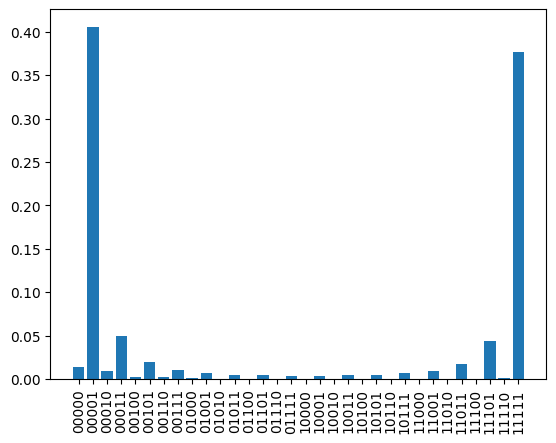

In [41]:
bit_strings = [f"{x:0{5}b}" for x in range(len(l1))]
plt.bar(bit_strings, l1)
plt.xticks(rotation=90)

In [25]:
IQubits = 0
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev3 = qml.device('default.qubit', wires=nQubits) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qnode(dev3)
def circuitMNSP(theta,Operator, AllExplorers=True):
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    H = np.kron(P1,np.eye(2**(QQubits -1)))
    return qml.probs(op= qml.Hermitian(H,wires=range(offsetL,offsetQ)))
    #return qml.expval(qml.Hermitian(H,wires=range(offsetL,offsetQ)))

f2 = qml.QNode(circuitMNSP, dev3)

In [33]:
l2 = f2(trained_weights2,Img_O[:2**IQubits],True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, '00000'),
  Text(1, 0, '00001'),
  Text(2, 0, '00010'),
  Text(3, 0, '00011'),
  Text(4, 0, '00100'),
  Text(5, 0, '00101'),
  Text(6, 0, '00110'),
  Text(7, 0, '00111'),
  Text(8, 0, '01000'),
  Text(9, 0, '01001'),
  Text(10, 0, '01010'),
  Text(11, 0, '01011'),
  Text(12, 0, '01100'),
  Text(13, 0, '01101'),
  Text(14, 0, '01110'),
  Text(15, 0, '01111'),
  Text(16, 0, '10000'),
  Text(17, 0, '10001'),
  Text(18, 0, '10010'),
  Text(19, 0, '10011'),
  Text(20, 0, '10100'),
  Text(21, 0, '10101'),
  Text(22, 0, '10110'),
  Text(23, 0, '10111'),
  Text(24, 0, '11000'),
  Text(25, 0, '11001'),
  Text(26, 0, '11010'),
  Text(27, 0, '11011'),
  Text(28, 0, '11100'),
  Text(29, 0, '11101'),
  Text(30, 0, '11110'),
  Text(31, 0, '11111')])

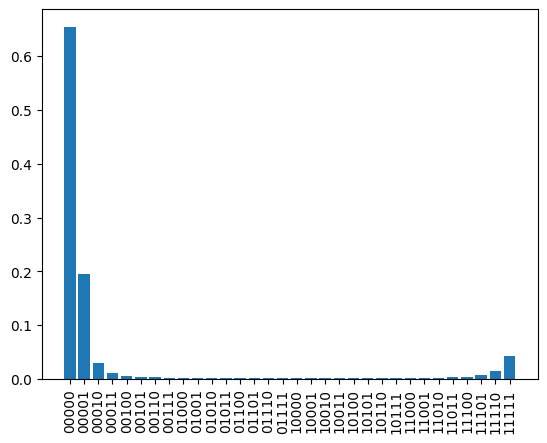

In [34]:
bit_strings = [f"{x:0{5}b}" for x in range(len(l2))]
plt.bar(bit_strings, l2)
plt.xticks(rotation=90)

In [37]:
theta_3 = np.zeros_like(trained_weights2)
l3 = f2(theta_3,Img_O[:2**IQubits],True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, '00000'),
  Text(1, 0, '00001'),
  Text(2, 0, '00010'),
  Text(3, 0, '00011'),
  Text(4, 0, '00100'),
  Text(5, 0, '00101'),
  Text(6, 0, '00110'),
  Text(7, 0, '00111'),
  Text(8, 0, '01000'),
  Text(9, 0, '01001'),
  Text(10, 0, '01010'),
  Text(11, 0, '01011'),
  Text(12, 0, '01100'),
  Text(13, 0, '01101'),
  Text(14, 0, '01110'),
  Text(15, 0, '01111'),
  Text(16, 0, '10000'),
  Text(17, 0, '10001'),
  Text(18, 0, '10010'),
  Text(19, 0, '10011'),
  Text(20, 0, '10100'),
  Text(21, 0, '10101'),
  Text(22, 0, '10110'),
  Text(23, 0, '10111'),
  Text(24, 0, '11000'),
  Text(25, 0, '11001'),
  Text(26, 0, '11010'),
  Text(27, 0, '11011'),
  Text(28, 0, '11100'),
  Text(29, 0, '11101'),
  Text(30, 0, '11110'),
  Text(31, 0, '11111')])

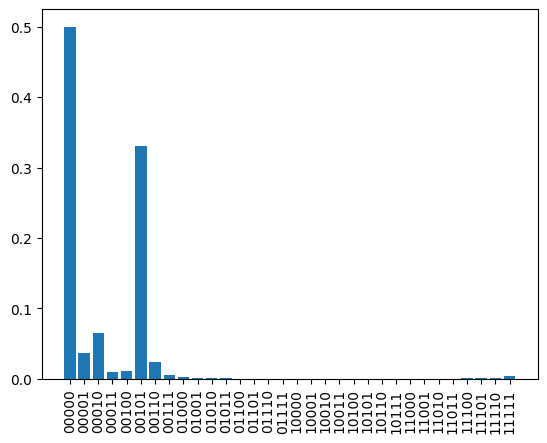

In [38]:
bit_strings = [f"{x:0{5}b}" for x in range(len(l3))]
plt.bar(bit_strings, l3)
plt.xticks(rotation=90)

In [ ]:
bit_strings = [f"{x:0{5}b}" for x in range(len(l3))]
bit_string2 = np.concatenate(bit_strings[:8],bit_strings[16:24])
x = np.arange(len(bit_strings))
x2 = np.arange(len(bit_string2))
l3_2 = np.concatenate((np.array(l3[:8]), np.array(l3[16:24])))
l2_2 = np.concatenate((np.array(l2[:8]), np.array(l2[16:24])))
l1_2 = np.concatenate((np.array(l1[:8]), np.array(l1[16:24])))
w = 0.3
# plt.bar(x - w, np.array(l3), width=w, label='No superposition(average case)', color='gray')
# plt.bar(x,       np.array(l2), width=w, label='No superposition(trained)', color='#6996b3')
# plt.bar(x + w,   np.array(l1), width=w, label='Superposition(trained)', color='#004c6d')
plt.bar(x - w, np.array(l3_2), width=w, label='No superposition(average case)', color='gray')
plt.bar(x,       np.array(l2_2), width=w, label='No superposition(trained)', color='#6996b3')
plt.bar(x + w,   np.array(l1_2), width=w, label='Superposition(trained)', color='#004c6d')
plt.ylabel('Probability')
plt.xticks(x, bit_strings)
plt.legend(frameon=False)
plt.tight_layout()
plt.xticks(rotation=90)

TypeError: 'list' object cannot be interpreted as an integer

In [48]:
btmp = bit_strings[:8]
btmp.append(bit_strings[16:24])
btmp


['00000',
 '00001',
 '00010',
 '00011',
 '00100',
 '00101',
 '00110',
 '00111',
 ['10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111']]

In [53]:
l3_2 = np.concatenate((np.array(l3[:8]), np.array(l3[16:24])))
# l2_2 = np.concatenate(l2[:8],l2[16:24])
# l1_2 = np.concatenate(l1[:8],l1[16:24])
print(l3_2)
# print(l2_2)
# print(l1_2)

[4.99656363e-01 3.69670400e-02 6.57532450e-02 9.71273010e-03
 1.16068882e-02 3.30809706e-01 2.37140149e-02 4.90269345e-03
 2.79556690e-04 2.61196342e-04 2.49828726e-04 2.44351764e-04
 2.44275150e-04 2.49620840e-04 2.60934661e-04 2.79416377e-04]


(32,)

In [3]:
def save_weights(weights, filename):
    import pickle

    with open(filename, 'wb') as file:
        pickle.dump(weights, file)

In [85]:
data = [trained_weights, trained_weights2]
save_weights(data, 'trained_weights.pkl')

In [26]:
import pickle
with open('trained_weights.pkl', 'rb') as file:
    a = pickle.load(file)

In [30]:
trained_weights = a[0]
trained_weights2 = a[1]

In [87]:
import os
os.getcwd()

'/pfs/data6/home/ka/ka_scc/ka_ov5178'

### Clasification circuit

In [ ]:
IQubits = 5
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev4 = qml.device('lightning.qubit', wires=nQubits+LQubits+QQubits+1) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qjit
@qml.qnode(dev4)
def circuitClasification(theta,Operator, O1, AllExplorers=True):

    # def Fidelity():
    #     # Multilayer
    #     for i in range(num_layers):
    #         Mottonen(theta[i],wire=range(nQubits+LQubits,nQubits+LQubits+QQubits),QQubits=QQubits, offset_U = offsetQ+QQubits)
        
    #     for i in range(LQubits):
    #         qml.Hadamard(wires=i+nQubits)
    #     for i in range(LQubits): 
    #         qml.ctrl(qml.QubitUnitary(Utils.powm(O1,i), wires=range(nQubits+LQubits,nQubits+QQubits)), control=nQubits+LQubits-1-i)
    #     qml.adjoint(qml.QFT(wires=range(nQubits, nQubits+LQubits)))
    #     qml.Hadamard(wires=nQubits+LQubits+QQubits-1)
    #     # qml.Barrier()
    #     for i in range(QQubits):
    #         qml.ctrl(qml.SWAP(wires=(offsetQ+i,nQubits+LQubits+i)), control=nQubits+LQubits+QQubits-1)
    #     qml.Hadamard(wires=nQubits+LQubits+QQubits-1)

    # def Nothing():
    #     for i in range(LQubits+QQubits):    
    #         qml.Hadamard(wires=i+nQubits)
    
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    c = qml.measure(offsetQ-1)
    #qml.cond(c==1,Fidelity,Nothing)
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(nQubits+LQubits,nQubits+LQubits+QQubits),QQubits=QQubits, offset_U = offsetQ+QQubits)
    
    for i in range(LQubits):
        qml.Hadamard(wires=i+nQubits)
    for i in range(LQubits): 
        qml.ctrl(qml.QubitUnitary(Utils.powm(O1,i), wires=range(nQubits+LQubits,nQubits+LQubits+QQubits)), control=nQubits+LQubits-1-i)
    qml.adjoint(qml.QFT(wires=range(nQubits, nQubits+LQubits)))
    qml.Barrier()
    qml.Hadamard(wires=nQubits+LQubits+QQubits)
    for i in range(QQubits):
        qml.ctrl(qml.SWAP(wires=(offsetQ+i,nQubits+LQubits+i)), control=nQubits+LQubits+QQubits)
    qml.Hadamard(wires=nQubits+LQubits+QQubits)
    H = np.kron(P1,np.eye(2**(LQubits -1)))
    return qml.expval(qml.Z(nQubits+LQubits+QQubits))
    #return [qml.measure(offsetQ-1),qml.expval(qml.Z(nQubits+LQubits+QQubits))]

CMClasification = qml.QNode(circuitClasification, dev4)

(<Figure size 4700x2700 with 1 Axes>, <Axes: >)


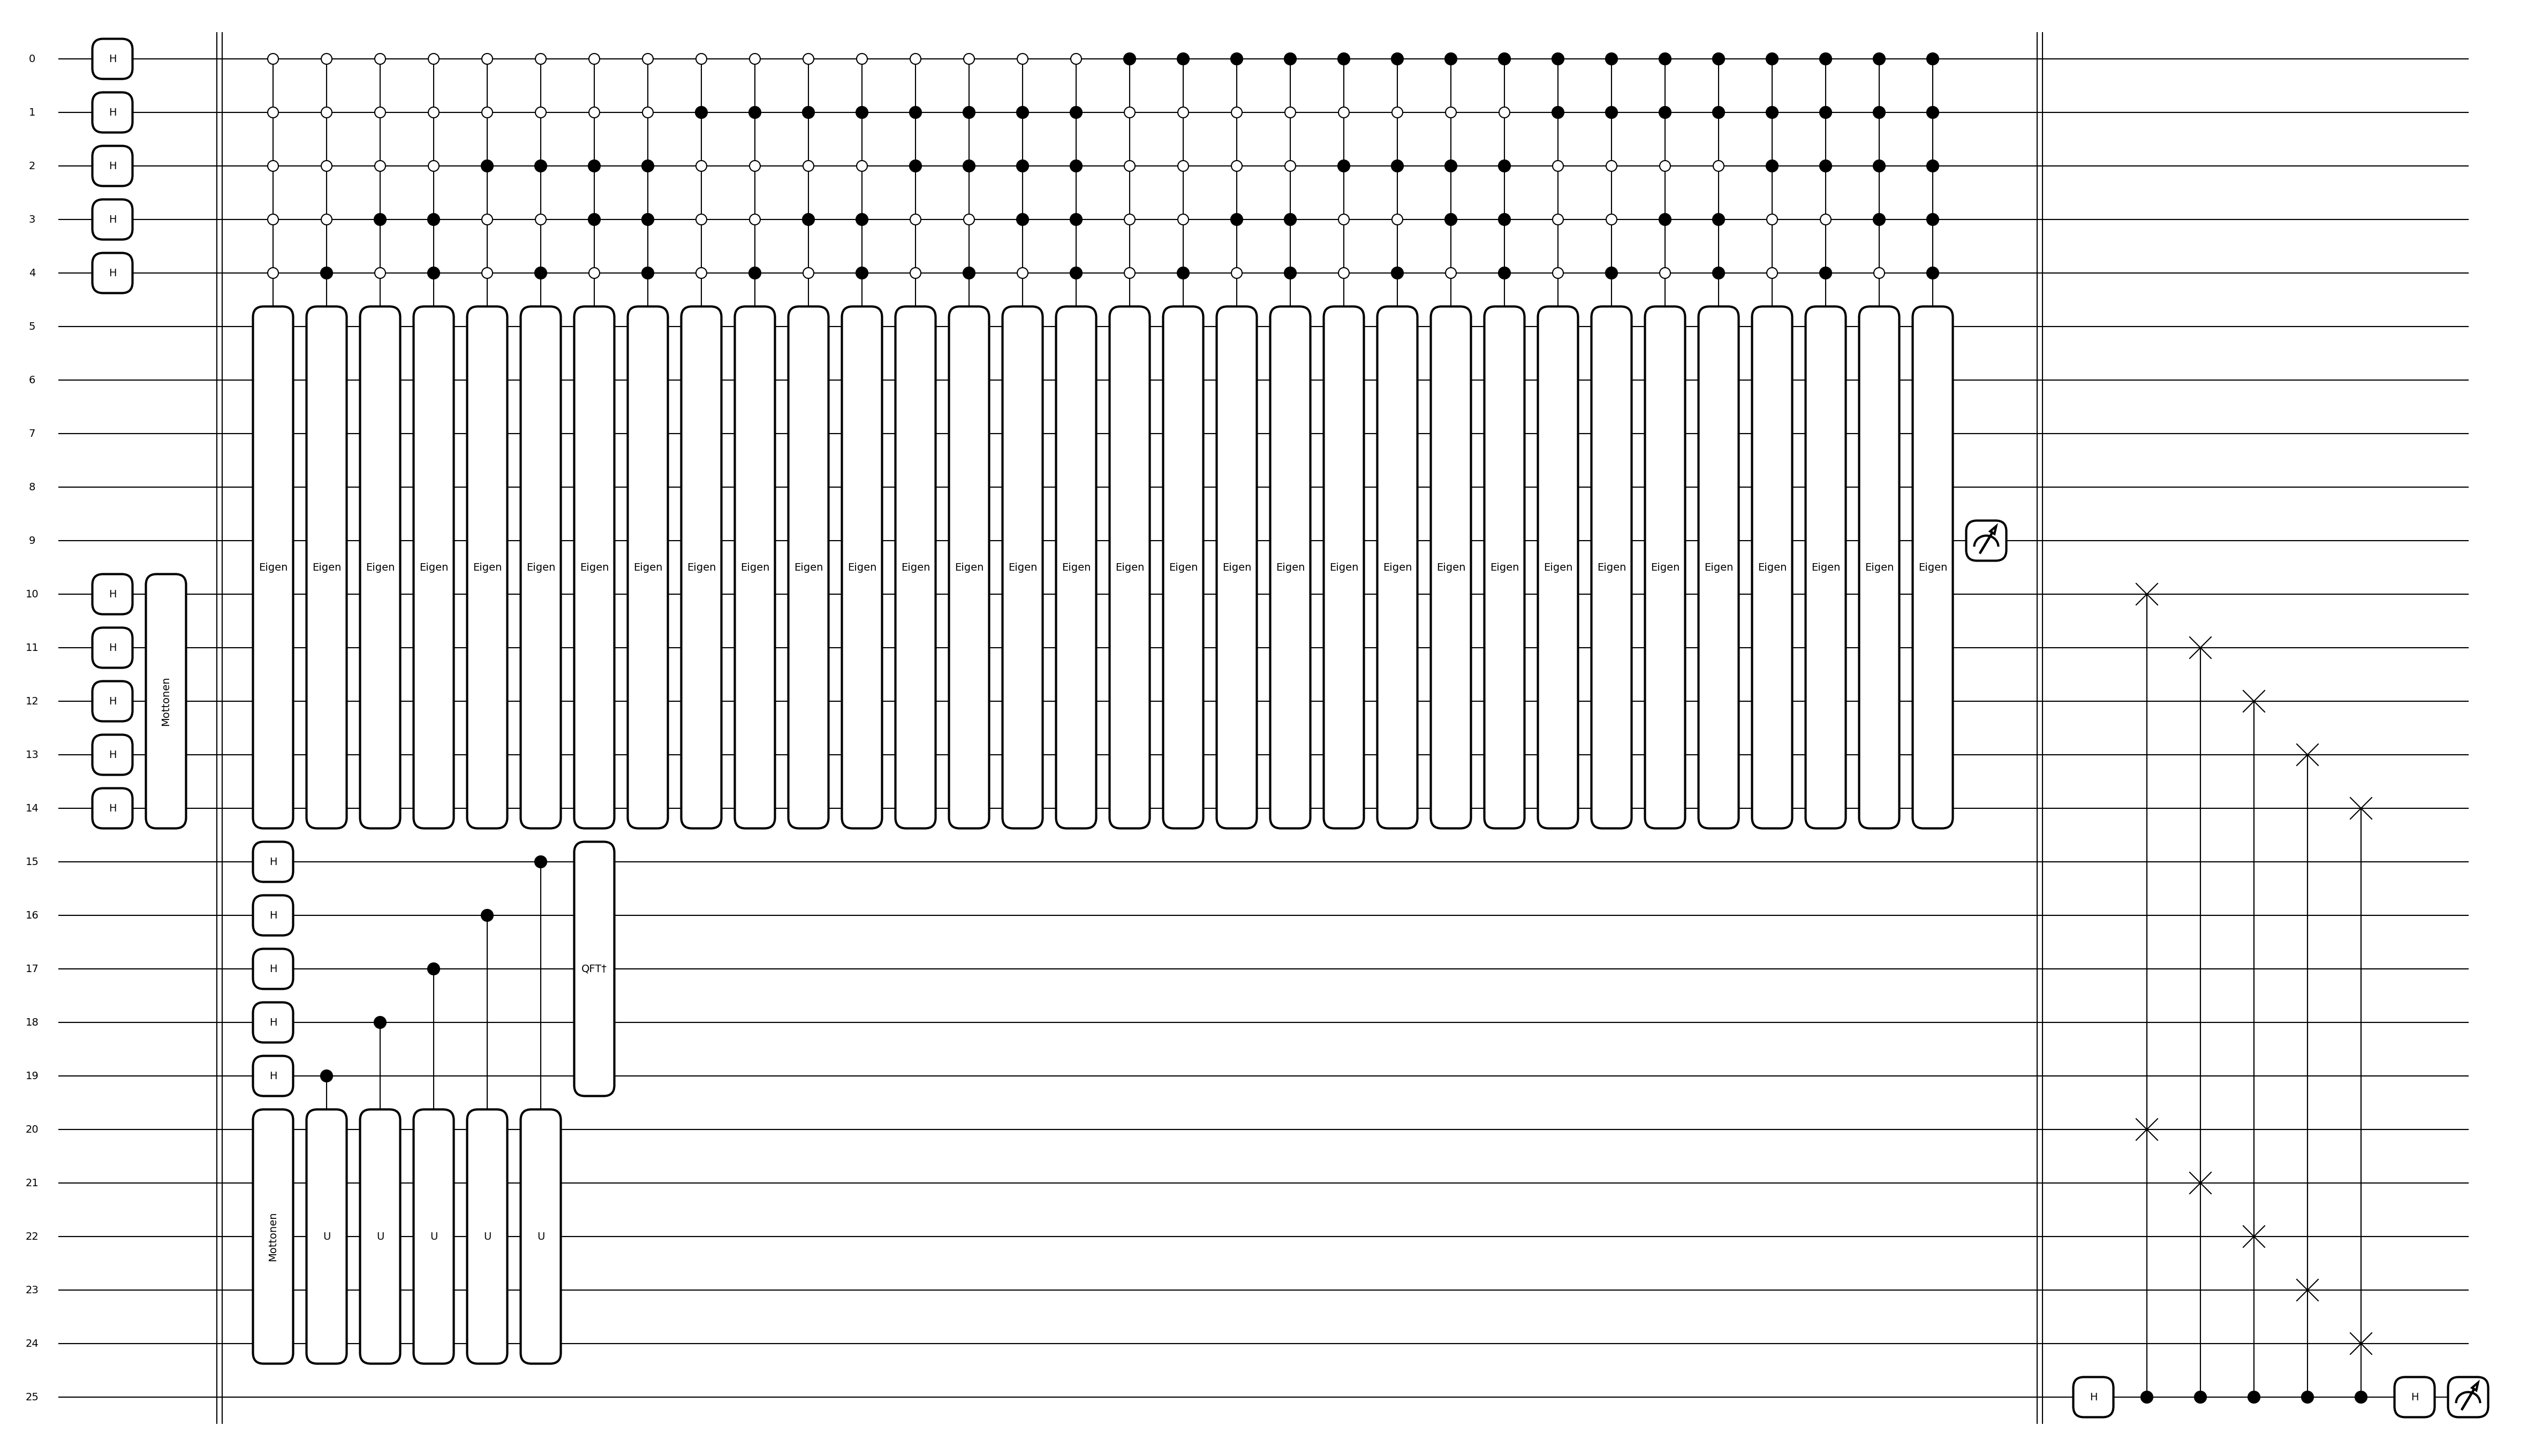

In [55]:
print(qml.draw_mpl(CMClasification)(trained_weights,Img_O[:2**IQubits],Img_O[0],True))

In [21]:
c1 = CMClasification(weights_superposition,Img_O[:2**IQubits],Img_O[0],True)

In [22]:
print(c1)

0.3245277176262016


In [63]:
print(l)

0.3245277176261274


In [35]:
IQubits = 5
PQubits = 0
LQubits = 5
QQubits = 5
offsetL = PQubits + IQubits
offsetQ = PQubits + IQubits + LQubits
nQubits = IQubits + PQubits + LQubits + QQubits
dev4 = qml.device('lightning.qubit', wires=nQubits+LQubits+QQubits+1) #lightning.gpu, default.qubit.tf
#dev4 = qml.device('lightning.qubit', wires=nQubits+LQubits+QQubits+1) #lightning.gpu, default.qubit.tf
#dev2 = qml.device('qulacs.simulator', wires=nQubits) 
num_layers = 1

@qml.qjit
@qml.qnode(dev4)
def circuitClasification2(theta,Operator, O1, AllExplorers=True):

    def Fidel():
        qml.Hadamard(wires=nQubits+LQubits+QQubits)
        for i in range(QQubits):
            qml.ctrl(qml.SWAP(wires=(offsetQ+i,nQubits+LQubits+i)), control=nQubits+LQubits+QQubits)
        qml.Hadamard(wires=nQubits+LQubits+QQubits)

    
    def TestOperator():
        for i in range(num_layers):
            Mottonen(theta[i],wire=range(nQubits+LQubits,nQubits+LQubits+QQubits),QQubits=QQubits, offset_U = offsetQ+QQubits)
        
        for i in range(LQubits):
            qml.Hadamard(wires=i+nQubits)
        for i in range(LQubits): 
            qml.ctrl(qml.QubitUnitary(Utils.powm(O1,i), wires=range(nQubits+LQubits,nQubits+LQubits+QQubits)), control=nQubits+LQubits-1-i)
        qml.adjoint(qml.QFT(wires=range(nQubits, nQubits+LQubits)))
        qml.Barrier()
        c2 = qml.measure(offsetL+LQubits+QQubits)
        qml.cond(c2==1,Fidel)
    # def Nothing():
    #     for i in range(LQubits+QQubits):    
    #         qml.Hadamard(wires=i+nQubits)
    
    # Proyector |1><1|
    for i in range(IQubits):
        qml.Hadamard(wires=i)
    P1 = np.array([[0,0],[0,1]])
    if AllExplorers:
        for i in range(offsetQ,nQubits):
            qml.Hadamard(wires=i)
    # Multilayer
    for i in range(num_layers):
        Mottonen(theta[i],wire=range(offsetQ,nQubits),QQubits=QQubits, offset_U = offsetQ)
    qml.Barrier()
    if IQubits>0:
        for i in range(2**IQubits):
            qml.ctrl(
                Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[i]),
                    control=range(IQubits), control_values=Utils.int_to_bin(n=i, num_bits=IQubits))
    else:
        Eigen(theta=theta, wire=range(offsetL,nQubits), IndexQubits=IQubits, LQubits=LQubits, QQubits=QQubits, O=Operator[0])
    c1 = qml.measure(offsetL)
    qml.cond(c1==1,TestOperator)
    # for i in range(num_layers):
    #     Mottonen(theta[i],wire=range(nQubits+LQubits,nQubits+LQubits+QQubits),QQubits=QQubits, offset_U = offsetQ+QQubits)
    
    # for i in range(LQubits):
    #     qml.Hadamard(wires=i+nQubits)
    # for i in range(LQubits): 
    #     qml.ctrl(qml.QubitUnitary(Utils.powm(O1,i), wires=range(nQubits+LQubits,nQubits+LQubits+QQubits)), control=nQubits+LQubits-1-i)
    # qml.adjoint(qml.QFT(wires=range(nQubits, nQubits+LQubits)))
    # qml.Barrier()
    # qml.Hadamard(wires=nQubits+LQubits+QQubits)
    # for i in range(QQubits):
    #     qml.ctrl(qml.SWAP(wires=(offsetQ+i,nQubits+LQubits+i)), control=nQubits+LQubits+QQubits)
    # qml.Hadamard(wires=nQubits+LQubits+QQubits)
    #H = np.kron(P1,np.eye(2**(QQubits -1)))

    #return qml.expval(qml.Hermitian(H,wires=range(offsetL, nQubits+LQubits+QQubits)))
    return qml.expval(qml.Z(nQubits+LQubits+QQubits))
    #return [qml.measure(offsetQ-1),qml.expval(qml.Z(nQubits+LQubits+QQubits))]

CMClasification2 = qml.QNode(circuitClasification2, dev4)

(<Figure size 3900x1700 with 1 Axes>, <Axes: >)


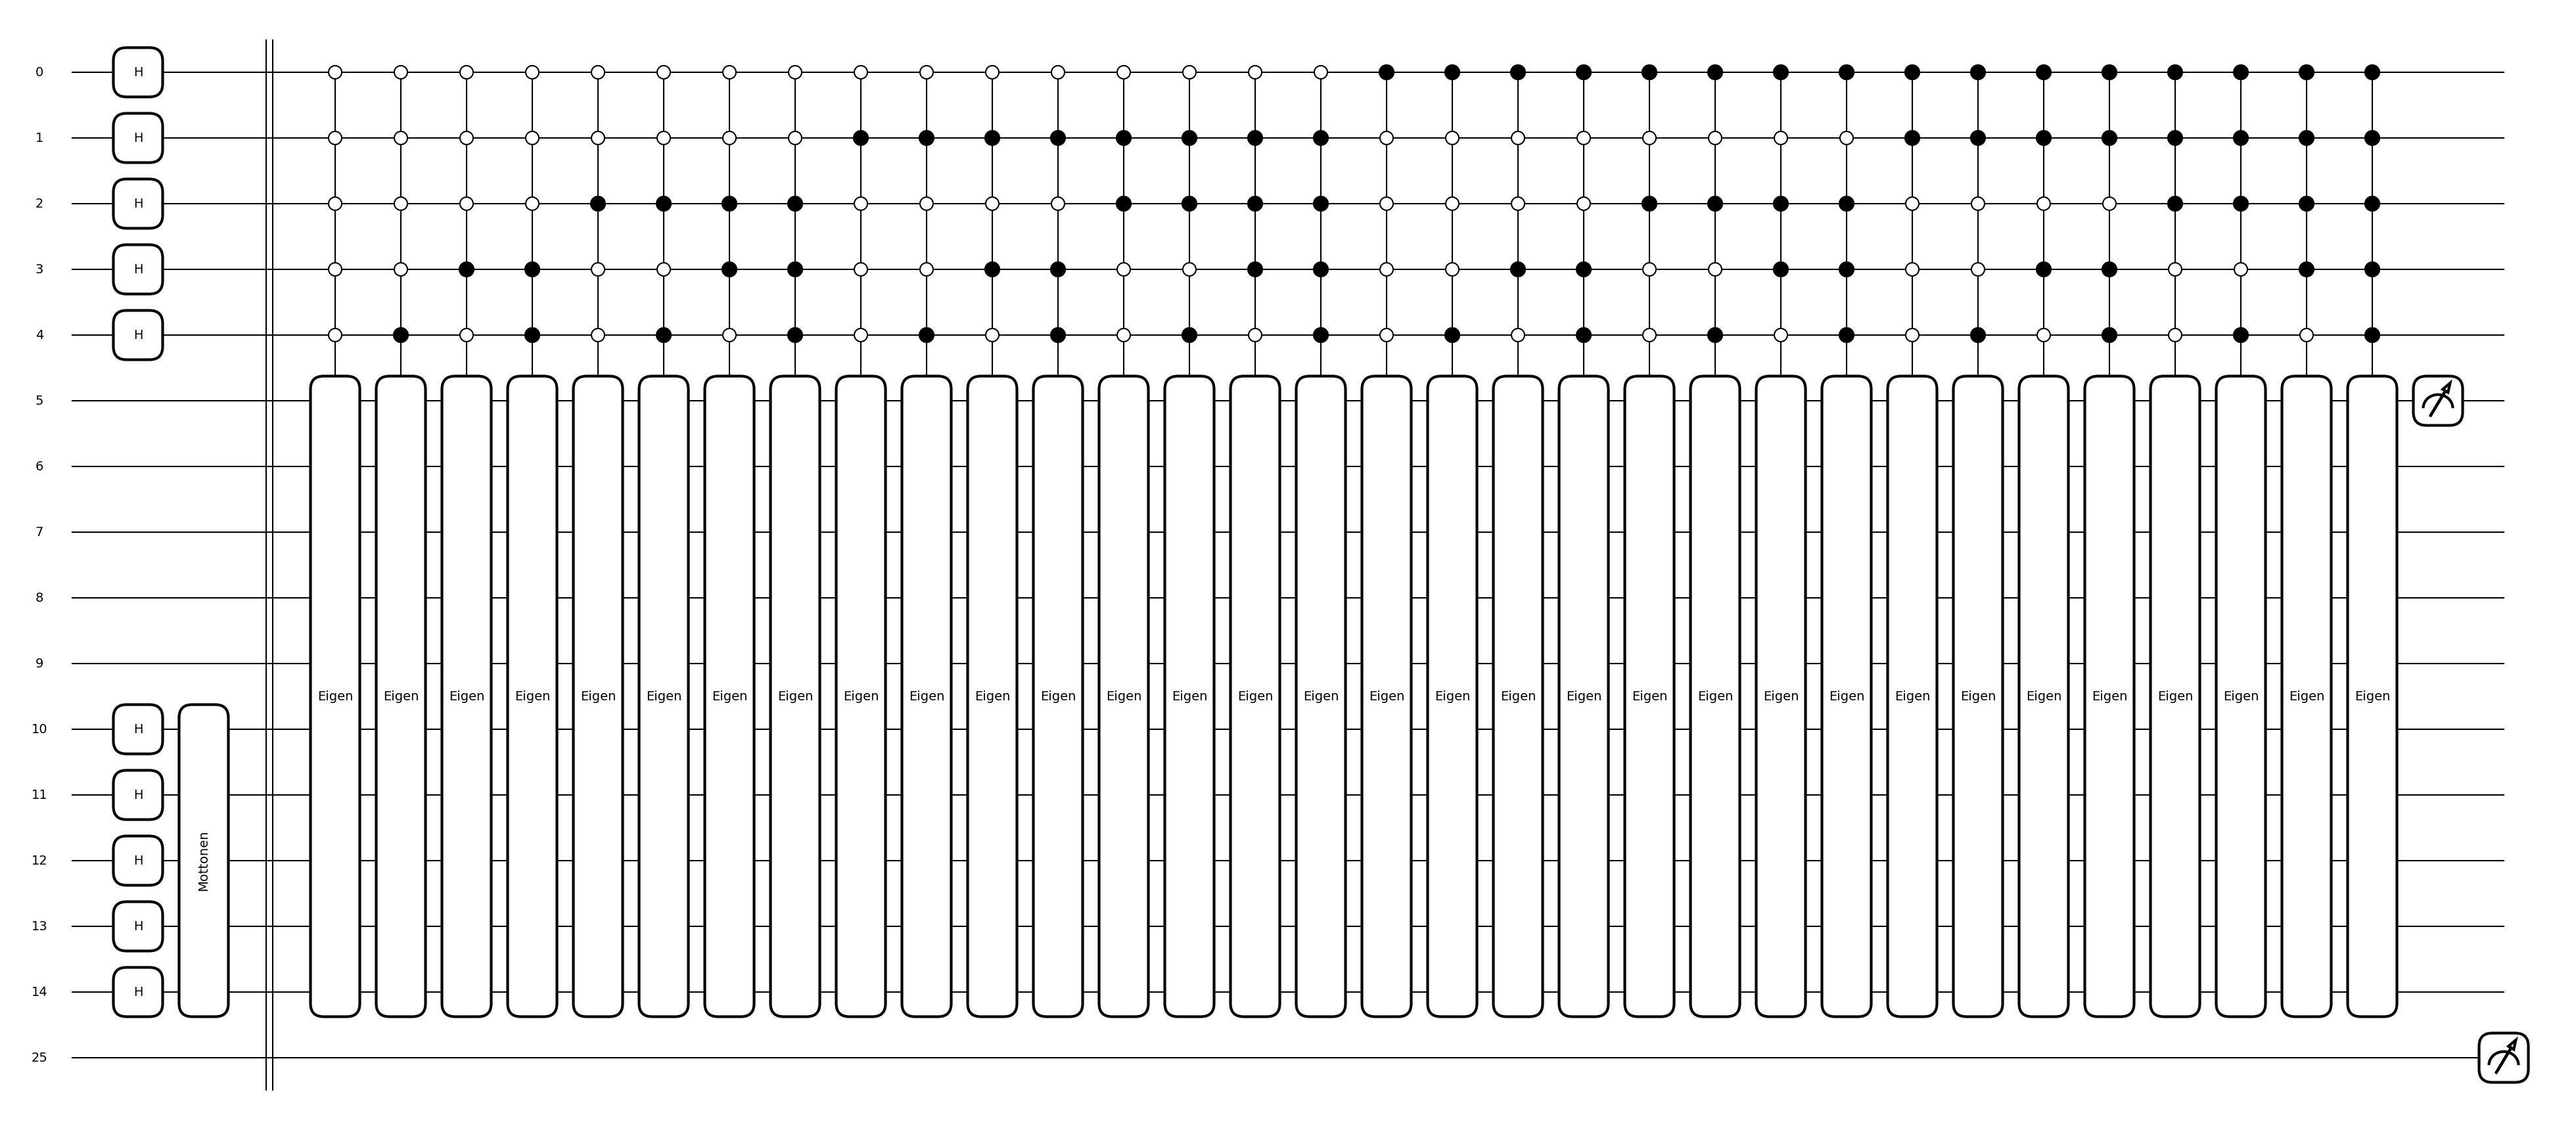

In [36]:
print(qml.draw_mpl(CMClasification2)(weights_superposition,Img_O[:2**IQubits],Img_O[0],True))

In [37]:
c2 = CMClasification2(weights_superposition,Img_O[:2**IQubits],Img_O[0],True)
print(c2)

0.9999999999999973


In [26]:
c3 = CMClasification2(weights_superposition,Img_O[:2**IQubits],expm(1j*np.cov(Image2)),True)
print(c3)

0.9999999999999973


In [27]:
c4 = CMClasification(weights_superposition,Img_O[:2**IQubits],expm(1j*np.cov(Image2)),True)
print(c4)

0.3245277176262016


In [2]:
dev = qml.device("lightning.qubit", wires=1)

@qml.qjit
@qml.qnode(dev)
def circuit(x: float):
    def ansatz_true():
        qml.RX(x, wires=0)

    def ansatz_false():
        qml.RY(x, wires=0)

    qml.cond(x > 1.4, ansatz_true, ansatz_false)()

    return qml.expval(qml.Z(0))

ansatz_true = circuit(1.4)
ansatz_false = circuit(1.6)

(<Figure size 400x200 with 1 Axes>, <Axes: >)

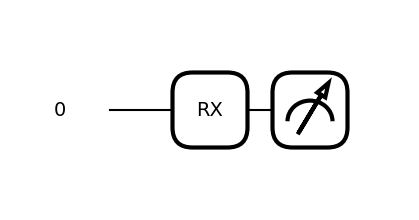

In [53]:
qml.draw_mpl(circuit)(1.6)

In [18]:
for i in range(10):
    r = CMClasification2(weights_superposition,Img_O[:2**IQubits],Img_O[0],True)
    print(r)
    

QuantumFunctionError: A quantum function must return either a single measurement, or a nonempty sequence of measurements.

In [ ]:
    H = np.kron(
        np.kron(P1,np.eye(2**(LQubits + QQubits -1))),np.kron(np.kron(P1,np.eye(2**(LQubits + QQubits -1))),P1)
        )


/pfs/data6/home/ka/ka_scc/ka_ov5178/Pennylane-Env/lib64/python3.11/site-packages/pennylane/measurements/probs.py:336: UserWarning: Using qml.probs with a Hermitian observable might return different results than expected as the lexicographical ordering of eigenvalues is not guaranteed.
  warnings.warn(


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, '00000'),
  Text(1, 0, '00001'),
  Text(2, 0, '00010'),
  Text(3, 0, '00011'),
  Text(4, 0, '00100'),
  Text(5, 0, '00101'),
  Text(6, 0, '00110'),
  Text(7, 0, '00111'),
  Text(8, 0, '01000'),
  Text(9, 0, '01001'),
  Text(10, 0, '01010'),
  Text(11, 0, '01011'),
  Text(12, 0, '01100'),
  Text(13, 0, '01101'),
  Text(14, 0, '01110'),
  Text(15, 0, '01111'),
  Text(16, 0, '10000'),
  Text(17, 0, '10001'),
  Text(18, 0, '10010'),
  Text(19, 0, '10011'),
  Text(20, 0, '10100'),
  Text(21, 0, '10101'),
  Text(22, 0, '10110'),
  Text(23, 0, '10111'),
  Text(24, 0, '11000'),
  Text(25, 0, '11001'),
  Text(26, 0, '11010'),
  Text(27, 0, '11011'),
  Text(28, 0, '11100'),
  Text(29, 0, '11101'),
  Text(30, 0, '11110'),
  Text(31, 0, '11111')])

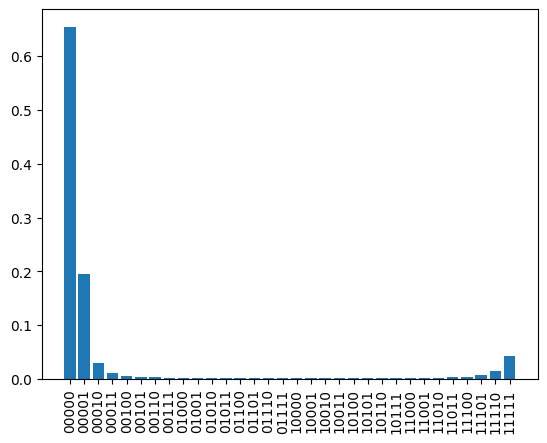

In [31]:
l2 = f2(weights_no_superposition,Img_O[:1],True)
bit_strings = [f"{x:0{5}b}" for x in range(len(l2))]
plt.bar(bit_strings, l2)
plt.xticks(rotation=90)